In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [3]:
# Load dataset
# Kalau file .xlsx pakai read_excel
# Kalau file .csv pakai read_csv
df = pd.read_excel('F:\Data Analyst\Make Portofolio\market_basket_analyst\online_retail.xlsx')

print("=== Shape Dataset ===")
print(f"Baris: {df.shape[0]:,}")
print(f"Kolom: {df.shape[1]}")

print("\n=== Nama Kolom ===")
print(df.columns.tolist())

print("\n=== 5 Data Pertama ===")
print(df.head())

print("\n=== Tipe Data ===")
print(df.dtypes)

print("\n=== Statistik Deskriptif ===")
print(df.describe())

=== Shape Dataset ===
Baris: 541,909
Kolom: 8

=== Nama Kolom ===
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

=== 5 Data Pertama ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Ki

In [12]:
# Cell 4 — Data Cleaning
print(f"Data sebelum cleaning: {len(df):,}")

# Step 1: Hapus baris dengan Description kosong
df = df.dropna(subset=['Description'])
print(f"Setelah hapus missing Description: {len(df):,}")

# Step 2: Hapus transaksi cancelled
# Fix: tambahkan fillna('') agar NaN tidak error
df['InvoiceNo'] = df['InvoiceNo'].astype(str).fillna('')
df = df[~df['InvoiceNo'].str.startswith('C')]
print(f"Setelah hapus transaksi cancelled: {len(df):,}")

# Step 3: Hapus Quantity negatif atau nol
df = df[df['Quantity'] > 0]
print(f"Setelah hapus quantity negatif: {len(df):,}")

# Step 4: Hapus UnitPrice negatif atau nol
df = df[df['UnitPrice'] > 0]
print(f"Setelah hapus harga negatif: {len(df):,}")

# Step 5: Bersihkan spasi di kolom Description
df['Description'] = df['Description'].str.strip().str.upper()

# Laporan akhir
print("\n" + "="*50)
print("LAPORAN HASIL CLEANING")
print("="*50)
data_hilang = 541909 - len(df)
pct_tersisa = len(df) / 541909 * 100
print(f"Data original  : 541,909")
print(f"Data dihapus   : {data_hilang:,}")
print(f"Data tersisa   : {len(df):,}")
print(f"Persentase     : {pct_tersisa:.1f}%")
print("\n✅ Data cleaning selesai!")

Data sebelum cleaning: 540,455
Setelah hapus missing Description: 540,455
Setelah hapus transaksi cancelled: 531,167
Setelah hapus quantity negatif: 530,693
Setelah hapus harga negatif: 530,104

LAPORAN HASIL CLEANING
Data original  : 541,909
Data dihapus   : 11,805
Data tersisa   : 530,104
Persentase     : 97.8%

✅ Data cleaning selesai!


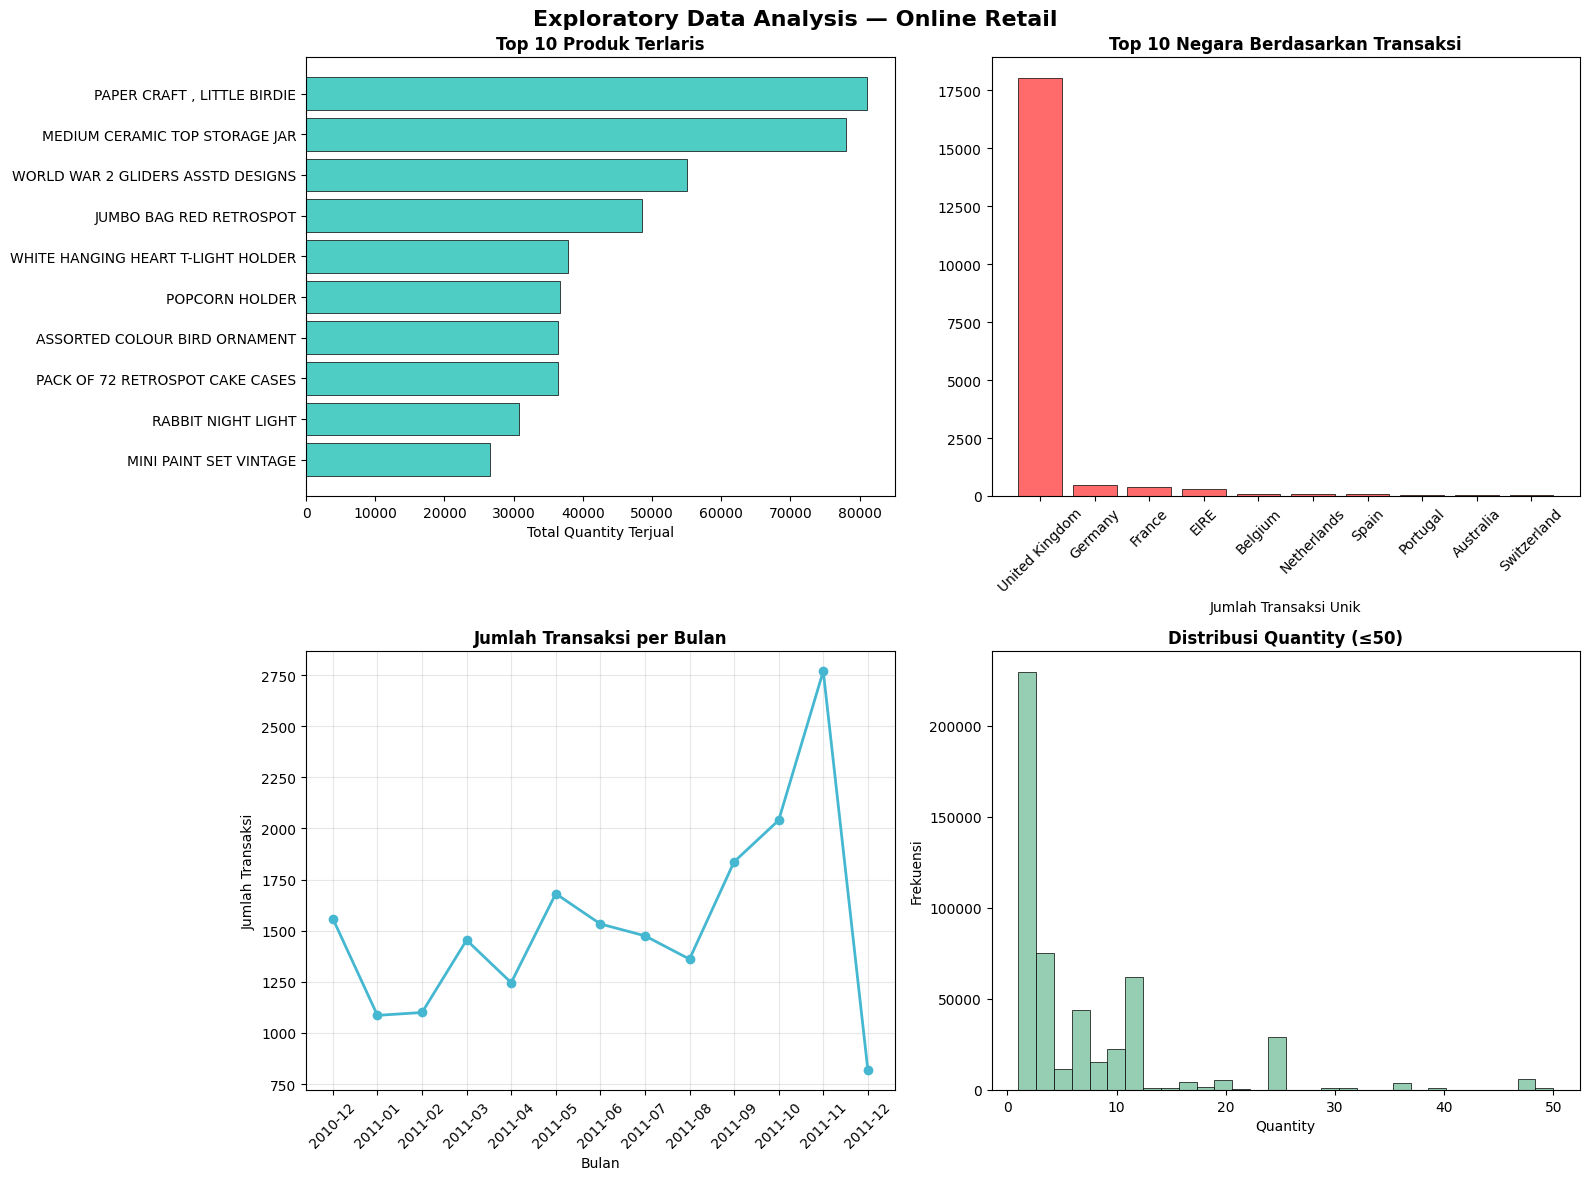

✅ EDA selesai!


In [13]:
# EDA
# Cell 5 — Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Online Retail', 
             fontsize=16, fontweight='bold')

# 1. Top 10 Produk Terlaris
top_products = df.groupby('Description')['Quantity']\
                 .sum().sort_values(ascending=False).head(10)

axes[0,0].barh(top_products.index, top_products.values, 
               color='#4ECDC4', edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Top 10 Produk Terlaris', fontweight='bold')
axes[0,0].set_xlabel('Total Quantity Terjual')
axes[0,0].invert_yaxis()

# 2. Top 10 Negara Berdasarkan Transaksi
top_countries = df.groupby('Country')['InvoiceNo']\
                  .nunique().sort_values(ascending=False).head(10)

axes[0,1].bar(top_countries.index, top_countries.values,
              color='#FF6B6B', edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Top 10 Negara Berdasarkan Transaksi', 
                     fontweight='bold')
axes[0,1].set_xlabel('Jumlah Transaksi Unik')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Transaksi per Bulan
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month')['InvoiceNo'].nunique()

axes[1,0].plot(monthly.index.astype(str), monthly.values,
               marker='o', color='#45B7D1', linewidth=2,
               markersize=6)
axes[1,0].set_title('Jumlah Transaksi per Bulan', 
                     fontweight='bold')
axes[1,0].set_xlabel('Bulan')
axes[1,0].set_ylabel('Jumlah Transaksi')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Distribusi Quantity per Transaksi
qty_dist = df[df['Quantity'] <= 50]['Quantity']
axes[1,1].hist(qty_dist, bins=30, color='#96CEB4', 
               edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Distribusi Quantity (≤50)', 
                     fontweight='bold')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_online_retail.png', dpi=150, 
            bbox_inches='tight')
plt.show()
print("✅ EDA selesai!")

In [15]:
# Karena mayoritas pembeli berasal dari UK kita filter khusus UK saja

# Cell 6 — Persiapan Data untuk Apriori

# Step 1: Filter hanya transaksi dari UK
df_uk = df[df['Country'] == 'United Kingdom'].copy()
print(f"Data UK: {len(df_uk):,} baris")
print(f"Transaksi unik UK: {df_uk['InvoiceNo'].nunique():,}")
print(f"Produk unik UK: {df_uk['Description'].nunique():,}")

# Step 2: Buat basket matrix
# Transformasi: 1 baris = 1 transaksi, 
#               1 kolom = 1 produk
# Nilai: 1 = dibeli, 0 = tidak dibeli


basket = df_uk.groupby(
            ['InvoiceNo', 'Description'])['Quantity']\
              .sum().unstack().fillna(0)

print(f"Shape basket matrix: {basket.shape}")
print(f"Artinya: {basket.shape[0]:,} transaksi × " 
      f"{basket.shape[1]:,} produk unik")

# Step 3: Encode ke format 0 dan 1
# (Apriori hanya butuh tahu: dibeli atau tidak)
def encode(x):
    return 1 if x > 0 else 0

basket_encoded = basket.applymap(encode)

print("\n=== Preview Basket Matrix ===")
print(basket_encoded.iloc[:5, :5])
print("\n✅ Basket matrix siap!")

Data UK: 485,123 baris
Transaksi unik UK: 18,019
Produk unik UK: 3,996

⏳ Membuat basket matrix...
Shape basket matrix: (18019, 3996)
Artinya: 18,019 transaksi × 3,996 produk unik

=== Preview Basket Matrix ===
Description  *BOOMBOX IPOD CLASSIC  *USB OFFICE MIRROR BALL  \
InvoiceNo                                                     
536365                           0                        0   
536366                           0                        0   
536367                           0                        0   
536368                           0                        0   
536369                           0                        0   

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536365                            0                           0   
536366                            0                           0   
536367                            0                           0   
536368      

In [16]:
# Cell 7 — Apriori Algorithm

# Step 1: Jalankan Apriori
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.03,
    use_colnames=True,
    max_len=2  # maksimal 2 produk per kombinasi
)

print(f"✅ Frequent itemsets ditemukan: "
      f"{len(frequent_itemsets):,}")

# Step 2: Generate Association Rules
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

# Step 3: Filter berdasarkan confidence
rules = rules[rules['confidence'] >= 0.1]

# Step 4: Urutkan berdasarkan lift tertinggi
rules = rules.sort_values('lift', ascending=False)

print(f"✅ Association rules ditemukan: {len(rules):,}")
print(f"\n=== Top 10 Rules Tertinggi (by Lift) ===")
print(rules[['antecedents', 'consequents', 
             'support', 'confidence', 
             'lift']].head(10).to_string())

⏳ Menjalankan Apriori...
(Proses ini mungkin butuh 1-2 menit)
✅ Frequent itemsets ditemukan: 145
✅ Association rules ditemukan: 22

=== Top 10 Rules Tertinggi (by Lift) ===
                            antecedents                          consequents   support  confidence       lift
4      (PINK REGENCY TEACUP AND SAUCER)    (GREEN REGENCY TEACUP AND SAUCER)  0.031966    0.820513  15.863541
5     (GREEN REGENCY TEACUP AND SAUCER)     (PINK REGENCY TEACUP AND SAUCER)  0.031966    0.618026  15.863541
21    (ROSES REGENCY TEACUP AND SAUCER)     (PINK REGENCY TEACUP AND SAUCER)  0.030246    0.570084  14.632960
20     (PINK REGENCY TEACUP AND SAUCER)    (ROSES REGENCY TEACUP AND SAUCER)  0.030246    0.776353  14.632960
2   (GARDENERS KNEELING PAD CUP OF TEA)   (GARDENERS KNEELING PAD KEEP CALM)  0.030024    0.721333  14.474059
3    (GARDENERS KNEELING PAD KEEP CALM)  (GARDENERS KNEELING PAD CUP OF TEA)  0.030024    0.602450  14.474059
6     (GREEN REGENCY TEACUP AND SAUCER)    (ROSES REGENCY

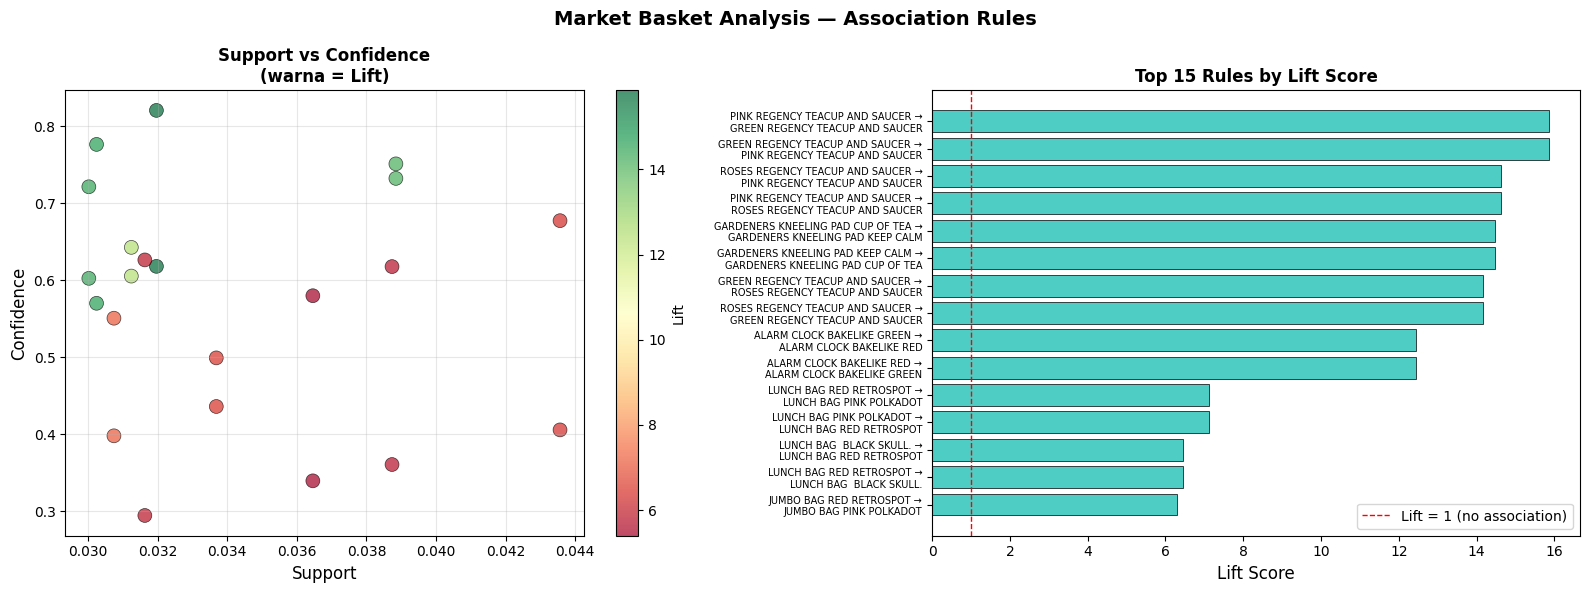

✅ Visualisasi selesai!


In [17]:
# Cell 8 — Visualisasi Association Rules
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Market Basket Analysis — Association Rules',
             fontsize=14, fontweight='bold')

# 1. Scatter Plot: Support vs Confidence
scatter = axes[0].scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='RdYlGn',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Support vs Confidence\n(warna = Lift)',
                   fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Bar Chart: Top 15 Rules by Lift
top_rules = rules.head(15).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str)\
                    .str.replace("frozenset({'", "")\
                    .str.replace("'})", "")\
                    + ' →\n' + \
                    top_rules['consequents'].astype(str)\
                    .str.replace("frozenset({'", "")\
                    .str.replace("'})", "")

axes[1].barh(range(len(top_rules)), 
             top_rules['lift'].values,
             color='#4ECDC4', 
             edgecolor='black', 
             linewidth=0.5)
axes[1].set_yticks(range(len(top_rules)))
axes[1].set_yticklabels(top_rules['rule'].values, 
                         fontsize=7)
axes[1].set_xlabel('Lift Score', fontsize=12)
axes[1].set_title('Top 15 Rules by Lift Score',
                   fontweight='bold')
axes[1].axvline(x=1, color='red', 
                linestyle='--', 
                linewidth=1,
                label='Lift = 1 (no association)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('mba_visualization.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Visualisasi selesai!")

In [18]:
# Cell 9 — Business Insight & Rekomendasi
print("=" * 60)
print("MARKET BASKET ANALYSIS — BUSINESS INSIGHTS")
print("=" * 60)

# 1. Tampilkan semua rules dengan format rapi
print("\n📊 SEMUA ASSOCIATION RULES:")
print("-" * 60)

rules_display = rules.copy()
rules_display['antecedents'] = rules_display['antecedents']\
    .apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents']\
    .apply(lambda x: ', '.join(list(x)))

for idx, row in rules_display.iterrows():
    print(f"\n🛒 Rule #{rules_display.index.get_loc(idx)+1}")
    print(f"   IF     : {row['antecedents']}")
    print(f"   THEN   : {row['consequents']}")
    print(f"   Support    : {row['support']:.3f} "
          f"({row['support']*100:.1f}% transaksi)")
    print(f"   Confidence : {row['confidence']:.3f} "
          f"({row['confidence']*100:.1f}% kemungkinan)")
    print(f"   Lift       : {row['lift']:.2f}x lebih mungkin")

# 2. Kategori Rules berdasarkan Lift
print("\n\n" + "=" * 60)
print("📈 KATEGORISASI RULES BERDASARKAN KEKUATAN")
print("=" * 60)

very_strong = rules[rules['lift'] >= 10]
strong = rules[(rules['lift'] >= 7) & (rules['lift'] < 10)]
moderate = rules[(rules['lift'] >= 5) & (rules['lift'] < 7)]

print(f"\n🟢 SANGAT KUAT (Lift ≥ 10) : {len(very_strong)} rules")
for _, row in very_strong.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"   → {ant} → {con} (Lift: {row['lift']:.2f})")

print(f"\n🟡 KUAT (Lift 7-10)        : {len(strong)} rules")
for _, row in strong.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"   → {ant} → {con} (Lift: {row['lift']:.2f})")

print(f"\n🔴 SEDANG (Lift 5-7)       : {len(moderate)} rules")
print(f"   ({len(moderate)} rules — lihat tabel lengkap)")

# 3. Rekomendasi Bisnis
print("\n\n" + "=" * 60)
print("💡 REKOMENDASI STRATEGI BISNIS")
print("=" * 60)

print("""
1. 📦 PRODUCT BUNDLING (Prioritas Utama)
   → Buat bundle untuk semua rules dengan Lift ≥ 10
   → Tawarkan diskon 5-10% untuk pembelian bundle
   → Fokus pada Regency Teacup Collection

2. 🏪 PRODUCT PLACEMENT  
   → Tempatkan produk berasosiasi kuat bersebelahan
   → Gunakan signage "Frequently Bought Together"
   → Khususnya untuk rules dengan Confidence > 0.7

3. 📧 TARGETED MARKETING
   → Kirim rekomendasi produk via email/notifikasi
   → "Pelanggan yang membeli X juga membeli Y"
   → Prioritaskan VIP customers

4. 📊 INVENTORY MANAGEMENT
   → Pastikan produk berasosiasi kuat 
     selalu tersedia bersamaan
   → Jangan sampai salah satu habis 
     sementara pasangannya masih ada

5. 💰 REVENUE OPPORTUNITY
   → Rules dengan Support tertinggi = 
     potensi revenue terbesar
   → Fokus promosi di sini untuk 
     dampak maksimal
""")

print("✅ Business Insight selesai!")

MARKET BASKET ANALYSIS — BUSINESS INSIGHTS

📊 SEMUA ASSOCIATION RULES:
------------------------------------------------------------

🛒 Rule #1
   IF     : PINK REGENCY TEACUP AND SAUCER
   THEN   : GREEN REGENCY TEACUP AND SAUCER
   Support    : 0.032 (3.2% transaksi)
   Confidence : 0.821 (82.1% kemungkinan)
   Lift       : 15.86x lebih mungkin

🛒 Rule #2
   IF     : GREEN REGENCY TEACUP AND SAUCER
   THEN   : PINK REGENCY TEACUP AND SAUCER
   Support    : 0.032 (3.2% transaksi)
   Confidence : 0.618 (61.8% kemungkinan)
   Lift       : 15.86x lebih mungkin

🛒 Rule #3
   IF     : ROSES REGENCY TEACUP AND SAUCER
   THEN   : PINK REGENCY TEACUP AND SAUCER
   Support    : 0.030 (3.0% transaksi)
   Confidence : 0.570 (57.0% kemungkinan)
   Lift       : 14.63x lebih mungkin

🛒 Rule #4
   IF     : PINK REGENCY TEACUP AND SAUCER
   THEN   : ROSES REGENCY TEACUP AND SAUCER
   Support    : 0.030 (3.0% transaksi)
   Confidence : 0.776 (77.6% kemungkinan)
   Lift       : 14.63x lebih mungkin

🛒 R